analysis:
look at queries and filter them into different complexity classes

In [ ]:
# importing necessary libraries
import yanex
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [ ]:
queries_path = Path("queries.jsonl")
results_path = Path("results/results.jsonl")
# queries_path = "C:/Users/soora/.yanex/experiments/3ef3165e/artifacts/queries.jsonl"
# results_path = "C:/Users/soora/.yanex/experiments/3ef3165e/artifacts/results.jsonl"

queries = [json.loads(line) for line in open(queries_path, "r", encoding="utf-8")]
results = [json.loads(line) for line in open(results_path, "r", encoding="utf-8")]

print(f"Loaded {len(queries)} queries and {len(results)} results")


Loaded 3 queries and 3 results


In [8]:
queries_df = pd.DataFrame(queries)
results_df = pd.DataFrame(results)

queries_df.head()
results_df.head()

,id,description,collection,status,wall_time_ms,executionTimeMillis,totalDocsExamined,totalKeysExamined,nReturned,winningPlanStage,indexUsed,error,timestamp,sample_results
0,Q1,"Retrieve recent highly-rated posts, sorted by ...",posts,success,80.853,214,75849,0,57,PROJECTION_SIMPLE,None,None,2026-05-12T14:06:53.907816+00:00,"[{'ownerUserId': 723470, 'score': 57, 'viewCou..."
1,Q1,Find users created after a specific date with ...,users,success,13.096,69,23059,0,0,PROJECTION_DEFAULT,None,None,2026-05-12T14:06:54.362722+00:00,[]
2,Q1,Find posts created within a specific date rang...,posts,success,129.868,222,75849,0,20,PROJECTION_SIMPLE,None,None,2026-05-12T14:06:54.490873+00:00,"[{'ownerUserId': 946634, 'score': 7, 'viewCoun..."


In [9]:
df = queries_df.merge(results_df, on="id", how="inner")
df.head()

,id,description_x,collection_x,filter,projection,sort,limit,description_y,collection_y,status,wall_time_ms,executionTimeMillis,totalDocsExamined,totalKeysExamined,nReturned,winningPlanStage,indexUsed,error,timestamp,sample_results
0,Q1,"Retrieve recent highly-rated posts, sorted by ...",posts,{'creationDate': {'$gte': {'$date': '2022-01-0...,"{'title': 1, 'ownerUserId': 1, 'score': 1, 'vi...",{'viewCount': -1},100,"Retrieve recent highly-rated posts, sorted by ...",posts,success,80.853,214,75849,0,57,PROJECTION_SIMPLE,None,None,2026-05-12T14:06:53.907816+00:00,"[{'ownerUserId': 723470, 'score': 57, 'viewCou..."
1,Q1,"Retrieve recent highly-rated posts, sorted by ...",posts,{'creationDate': {'$gte': {'$date': '2022-01-0...,"{'title': 1, 'ownerUserId': 1, 'score': 1, 'vi...",{'viewCount': -1},100,Find users created after a specific date with ...,users,success,13.096,69,23059,0,0,PROJECTION_DEFAULT,None,None,2026-05-12T14:06:54.362722+00:00,[]
2,Q1,"Retrieve recent highly-rated posts, sorted by ...",posts,{'creationDate': {'$gte': {'$date': '2022-01-0...,"{'title': 1, 'ownerUserId': 1, 'score': 1, 'vi...",{'viewCount': -1},100,Find posts created within a specific date rang...,posts,success,129.868,222,75849,0,20,PROJECTION_SIMPLE,None,None,2026-05-12T14:06:54.490873+00:00,"[{'ownerUserId': 946634, 'score': 7, 'viewCoun..."
3,Q1,Find users created after a specific date with ...,users,{'creationDate': {'$gt': {'$date': '2020-01-01...,"{'displayName': 1, 'reputation': 1, 'location'...",{'reputation': -1},100,"Retrieve recent highly-rated posts, sorted by ...",posts,success,80.853,214,75849,0,57,PROJECTION_SIMPLE,None,None,2026-05-12T14:06:53.907816+00:00,"[{'ownerUserId': 723470, 'score': 57, 'viewCou..."
4,Q1,Find users created after a specific date with ...,users,{'creationDate': {'$gt': {'$date': '2020-01-01...,"{'displayName': 1, 'reputation': 1, 'location'...",{'reputation': -1},100,Find users created after a specific date with ...,users,success,13.096,69,23059,0,0,PROJECTION_DEFAULT,None,None,2026-05-12T14:06:54.362722+00:00,[]


# Complexity Classification

In [10]:
def classify_query(q):
    pipeline = q.get("pipeline")

    # Simple find query
    if pipeline is None:
        return "simple"

    stages = [list(stage.keys())[0] for stage in pipeline]
    n = len(stages)

    num_lookup = stages.count("$lookup")
    num_group = stages.count("$group")
    num_unwind = stages.count("$unwind")
    num_window = stages.count("$setWindowFields")
    num_facet = stages.count("$facet")

    # Simple
    if n <= 3 and num_lookup == 0 and num_group == 0:
        return "simple"

    # Moderate
    if n <= 6 and num_lookup <= 1 and num_window == 0:
        return "moderate"

    # Complex
    if num_window > 0 or num_facet > 0 or num_lookup >= 1:
        return "complex"

    return "complex"

In [11]:
df["complexity"] = df.apply(lambda row: classify_query(row), axis=1)

In [12]:
df["complexity"].value_counts()


complexity
simple    9
Name: count, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

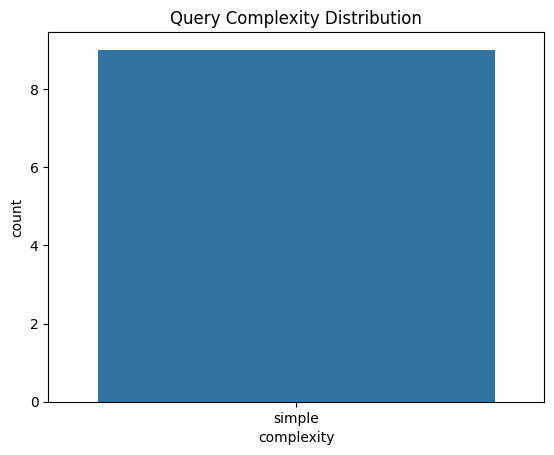

In [13]:
sns.countplot(data=df, x="complexity")
plt.title("Query Complexity Distribution")
plt.show

complexity
simple    74.605667
Name: wall_time_ms, dtype: float64